# Análisis de SBOM y vulnerabilidades

Este notebook analiza los resultados generados con Syft y Grype.

In [45]:
from pathlib import Path

BASE_DIR = Path("..")
RESULTS_DIR = BASE_DIR / "data" / "results"

In [46]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

In [47]:
files = list(RESULTS_DIR.glob("*_grype.json"))
files

[PosixPath('../data/results/claude-code-action_grype.json'),
 PosixPath('../data/results/flask_grype.json'),
 PosixPath('../data/results/genai-code-review_grype.json'),
 PosixPath('../data/results/jinja_grype.json'),
 PosixPath('../data/results/opencode_grype.json'),
 PosixPath('../data/results/requests_grype.json'),
 PosixPath('../data/results/werkzeug_grype.json')]

In [48]:
import json

results = []

for f in files:
    try:
        with open(f) as file:
            data = json.load(file)

        vulns = len(data.get("matches", []))
        results.append((f.stem, vulns))

    except json.JSONDecodeError:
        print(f"⚠️ JSON inválido ignorado: {f.name}")

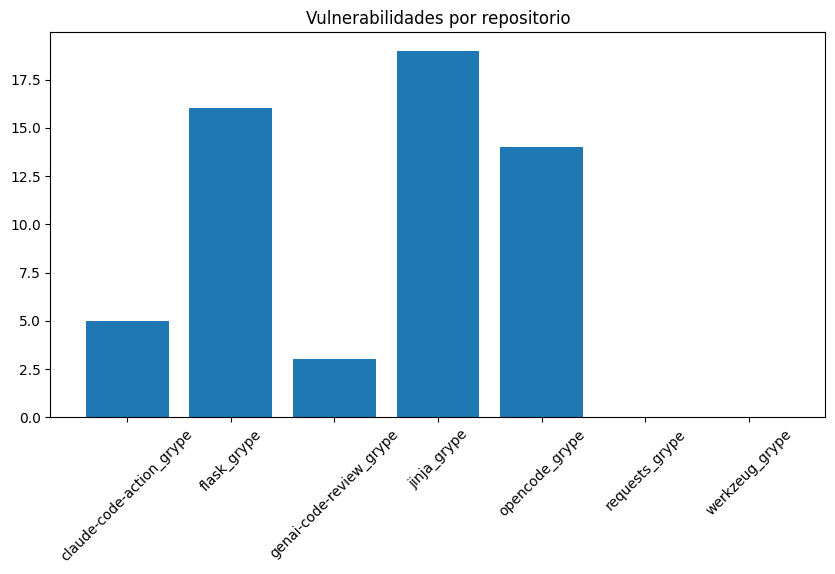

In [49]:
import matplotlib.pyplot as plt

names = [r[0] for r in results]
values = [r[1] for r in results]

plt.figure(figsize=(10, 5))
plt.bar(names, values)
plt.xticks(rotation=45)
plt.title("Vulnerabilidades por repositorio")
plt.show()

# Conclusiones

- Los repositorios presentan distintos niveles de vulnerabilidades
- Algunos repos tienen más exposición debido a mayor cantidad de dependencias
- La mayoría de vulnerabilidades son de severidad media